In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow_datasets as tfds

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [2]:
(data_train, data_val, data_test), data_info = tfds.load('cats_vs_dogs', 
                                               split=['train[:70%]', 'train[70%:85%]', 'train[85%:]'], 
                                               shuffle_files=True, 
                                               as_supervised=True, 
                                               with_info=True
                                               )

In [3]:
print("Traing set size: ", len(data_train))
print("Validation set size: ", len(data_val))
print("Test set size: ", len(data_test))

Traing set size:  16283
Validation set size:  3490
Test set size:  3489


In [4]:
cat_count = 0
dog_count = 0

for _, label in data_train:
    if label.numpy() == 0:
        cat_count += 1
    else:
        dog_count += 1

print("Cat count in training set: ", cat_count)
print("Dog count in training set: ", dog_count)

Cat count in training set:  8195
Dog count in training set:  8088


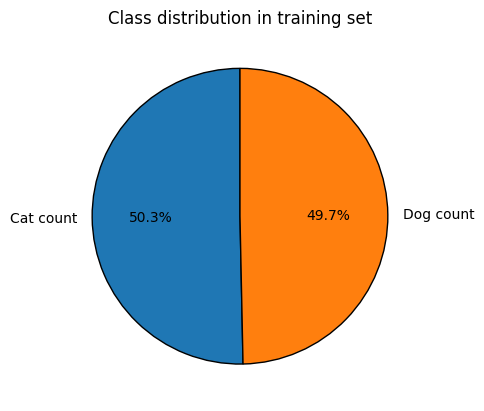

In [5]:
plt.pie([cat_count, dog_count], labels=["Cat count", "Dog count"], autopct= '%1.1f%%', startangle = 90, wedgeprops = {'edgecolor': 'black'})
plt.title("Class distribution in training set")
plt.show()

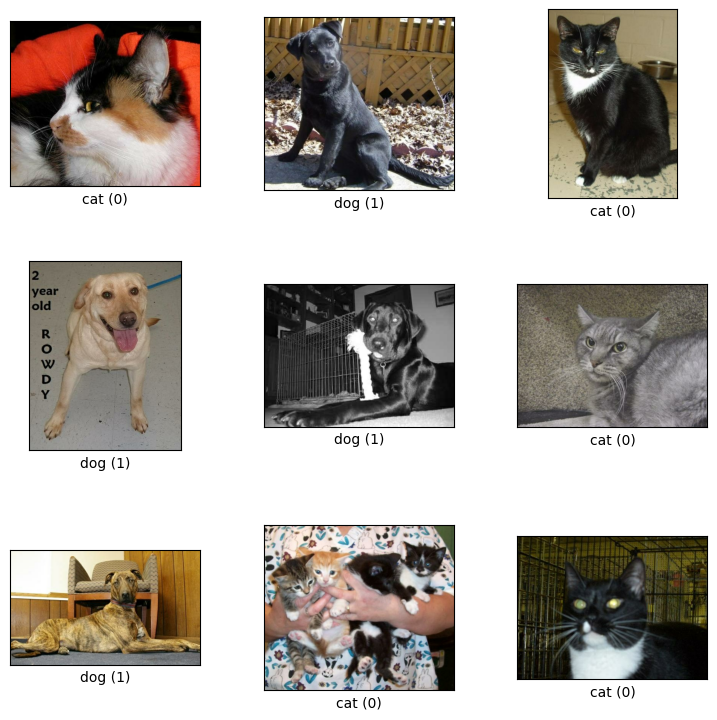

In [6]:
fig = tfds.show_examples(data_train, data_info)

In [7]:
cat_count = 0
dog_count = 0

for _, label in data_val:
    if label.numpy() == 0:
        cat_count += 1
    else:
        dog_count += 1

print("Cat count in val set: ", cat_count)
print("Dog count in val set: ", dog_count)

Cat count in val set:  1743
Dog count in val set:  1747


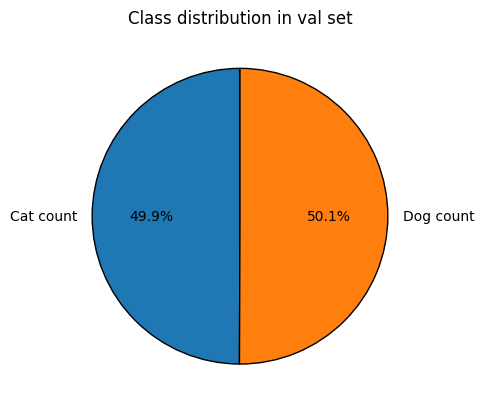

In [8]:
plt.pie([cat_count, dog_count], labels=["Cat count", "Dog count"], autopct= '%1.1f%%', startangle = 90, wedgeprops = {'edgecolor': 'black'})
plt.title("Class distribution in val set")
plt.show()

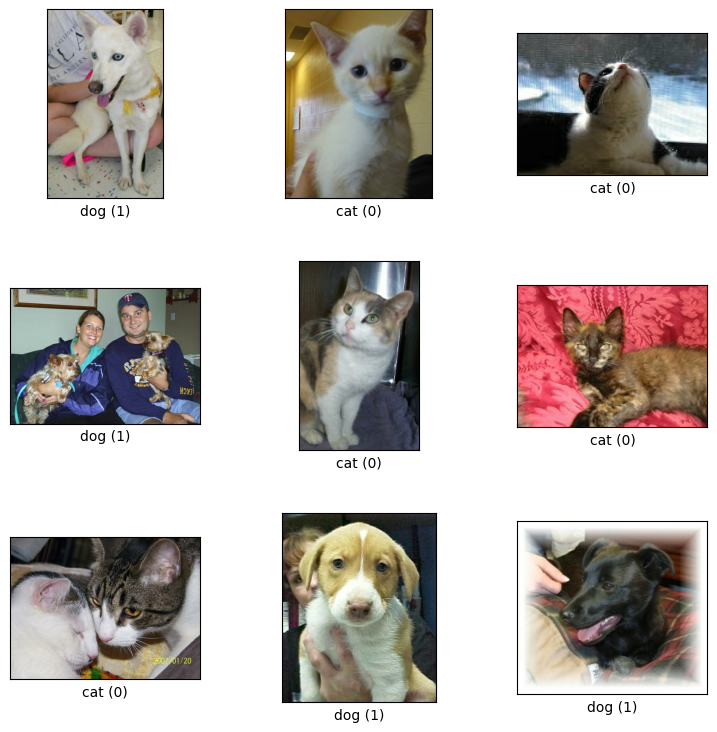

In [9]:
fig = tfds.show_examples(data_val, data_info)

In [10]:
cat_count = 0
dog_count = 0

for _, label in data_test:
    if label.numpy() == 0:
        cat_count += 1
    else:
        dog_count += 1

print("Cat count in test set: ", cat_count)
print("Dog count in test set: ", dog_count)

Cat count in test set:  1720
Dog count in test set:  1769


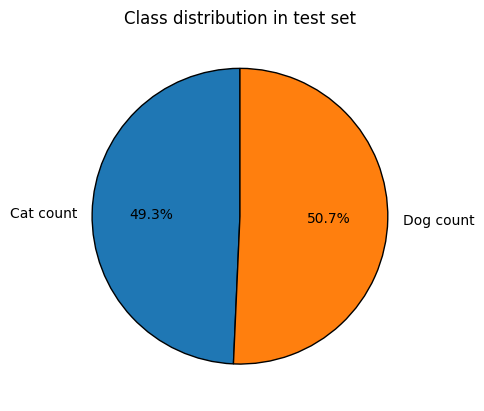

In [11]:
plt.pie([cat_count, dog_count], labels=["Cat count", "Dog count"], autopct= '%1.1f%%', startangle = 90, wedgeprops = {'edgecolor': 'black'})
plt.title("Class distribution in test set")
plt.show()

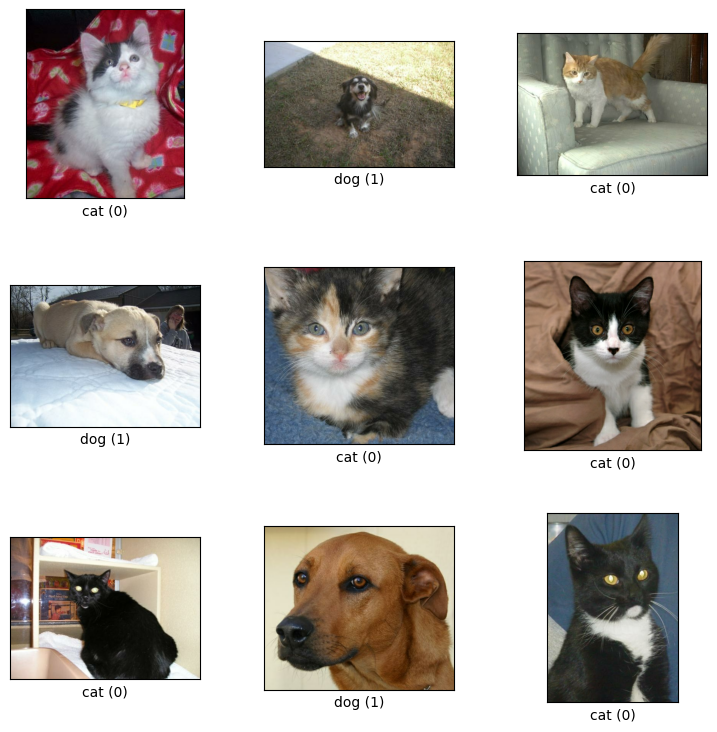

In [12]:
fig = tfds.show_examples(data_test, data_info)

In [13]:
def normalize_img(image, label):
    image = tf.image.resize(image, (128, 128))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

In [14]:
# Training pipeline
data_train = data_train.map(normalize_img)
# data_train = data_train.cache()
data_train = data_train.shuffle(data_info.splits["train[:70%]"].num_examples)
data_train = data_train.batch(32)

In [15]:
# Validation pipeline
data_val = data_val.map(normalize_img)
data_val = data_val.batch(32)
# data_val = data_val.cache()

In [16]:
# Testing pipeline
data_test = data_test.map(normalize_img)
data_test = data_test.batch(32)
# data_test = data_test.cache()

In [17]:
# Flat sequential model

model = keras.models.Sequential([
    layers.Input(shape = (128, 128, 3)),
    layers.Flatten(),
    layers.Dense(10, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

In [ ]:
model.compile(optimizer=keras.optimizers.Adam(0.001),
              loss = keras.losses.binary_crossentropy,
              metrics = [keras.metrics.BinaryAccuracy()])

: 

In [19]:
model.fit(data_train, epochs=10, validation_data=data_val)

Epoch 1/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 27s 15ms/step - binary_accuracy: 0.5004 - loss: 0.7376 - val_binary_accuracy: 0.4994 - val_loss: 0.6932
Epoch 2/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - binary_accuracy: 0.5014 - loss: 0.6932 - val_binary_accuracy: 0.4994 - val_loss: 0.6931
Epoch 3/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - binary_accuracy: 0.5003 - loss: 0.6932 - val_binary_accuracy: 0.4994 - val_loss: 0.6932
Epoch 4/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - binary_accuracy: 0.4974 - loss: 0.6932 - val_binary_accuracy: 0.4994 - val_loss: 0.6932
Epoch 5/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - binary_accuracy: 0.5024 - loss: 0.6932 - val_binary_accuracy: 0.4994 - val_loss: 0.6932
Epoch 6/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - binary_accuracy: 0.5033 - loss: 0.6932 - val_binary_accuracy: 0.4994 - val_loss: 0.6932
Epoch 7/10


: 

: 